Building a logistic regression model, given some training data, define our hypothesis, cost funtion and implement gradient descent algorithm to optimize the cost funtion to find the best parameters (vector $\mathbf{w} = [w_0, w_1, \dots, w_n]$). Steps:

1). check the data, load the data into correct format, and plot the data.

2). implement a function to compute cost funtion $E(\mathbf{w})$.

3). implement a function for gradient descent algorithm.

4). with the training data, run gradient descent algorithm, and find best parameters and predict on unseen data (test data).

5). find a real world data yourself and explore.





In [ ]:
# prompt: mount google drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [28]:
!ls '/content/drive/MyDrive/Colab Notebooks/Logistic_Regression'

a2data1.txt  a2data2.txt  regression.ipynb


## 1. Load and Visualizing the data

Build a logistic regression model to predict whether a student gets admitted into a university.

Suppose an administrator of a university department wants to determine each applicant’s chance of admission based on their results on two exams. You have historical data from previous applicants that you can use as a training set for logistic regression. For each training example, you have the applicant’s scores on two exams and the admissions decision.

Your task is to build a classification model that estimates an applicant’s probability of admission based on the scores from two exams.

Before starting to implement any learning algorithm, it is always good to visualize the data if possible.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [29]:
# loading file to array data
data = np.loadtxt('drive/MyDrive//Colab Notebooks/Logistic_Regression/a2data1.txt', delimiter=",")
print(data.shape)
print(data[:5, :])

(100, 3)
[[34.62365962 78.02469282  0.        ]
 [30.28671077 43.89499752  0.        ]
 [35.84740877 72.90219803  0.        ]
 [60.18259939 86.3085521   1.        ]
 [79.03273605 75.34437644  1.        ]]


As we can see, the first two columns are the features (scores on two exams), and the last column contain the target label (0 means no, 1 means yes in terms of admission). Now, we need to put the training examples's features (two scores) into the feature matrices $X$, and lables to a vector $y$.

In [ ]:
# get training examples features into X and the labels to y
X = data[:, :2]
y = data[:, -1]


print(f'The shape of the features matrice, X: {X.shape}')
print(f'The shape of the labels matrice, y: {y.shape}')


The shape of the features matrice, X: (100, 2)
The shape of the labels matrice, y: (100,)


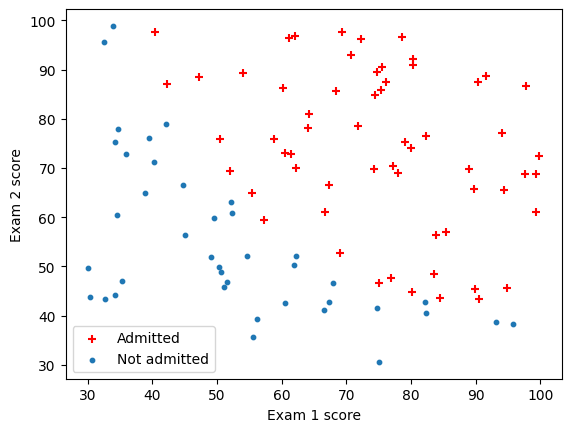

In [ ]:
# Visualize a scattered plot of Exam 1 and 2
pos , neg = (y==1).reshape(100,1) , (y==0).reshape(100,1)
plt.scatter(X[pos[:,0],0],X[pos[:,0],1],c="r",marker="+")
plt.scatter(X[neg[:,0],0],X[neg[:,0],1],marker="o",s=10)
plt.xlabel("Exam 1 score")
plt.ylabel("Exam 2 score")
plt.legend(["Admitted","Not admitted"],loc=0)

Using feature normalization first to transfer the data, and then
to work with neural networks, we will change $X$'s shape and $y$'s shape. To store each example as one column in $X$, which has dimensions (2, 100), and vector $y$ will be a row vector that has dimension (1, 100). This format will allow us to calculate $h_w(X) = sigmoid(w^T * X_{new})$ where $w = \begin{pmatrix}
    w_0  \\
    w_1  \\
    w_2  \\
\end{pmatrix}$ is a column vector and $X_{new}$ is the feature matrices with one additional feature $x_0$ added to $X$, $
X_{new}=
\begin{pmatrix}
    1, & 1, & ...,& 1 \\
    x_1^{(1)},& x_1^{(2)},&..., &x_1^{(100)} \\
    x_2^{(1)},& x_2^{(2)}, &...,&x_2^{(100)} \\
\end{pmatrix}$, so each training example will be a column in $X_{new}$.

-

In [ ]:
def featureNormalization(X):
    """ featureNormalization- Take in numpy array of X values and return normalize X values,
                              the mean and standard deviation of each feature                 """
    mean=np.mean(X,axis=0)
    std=np.std(X,axis=0)
    X_norm = (X - mean)/std

    return X_norm , mean , std

In [ ]:
# get number of training examples
N = data.shape[0]                  # should be 100

# normalize the features
X_norm, X_mean, X_std = featureNormalization(X)

# stack np.ones((1, N)) to X_form's transpose (2, 100)
# to get X_new with dimension (3, 100)
ones = np.ones((1, N))
X_new = np.vstack((ones, X_norm.T))

y = data[:, -1].reshape(1, N)
print(f"{X_new.shape}\n{X_new[:, :5]}\n{y.shape}")

(3, 100)
[[ 1.          1.          1.          1.          1.        ]
 [-1.60224763 -1.82625564 -1.53903969 -0.28210129  0.69152826]
 [ 0.63834112 -1.2075414   0.3612943   1.0863683   0.49337794]]
(1, 100)


## 2. Define Sigmoid function

Before defining $h_w$, we should define sigmoid function. Sigmoid function will squeeze the value from the linear regression hypothesis to be between (0, 1), to be evaluated as a probablity.

In [ ]:
def sigmoid(x):
    """ sigmoid- Computes the sigmoid of x
        Arguments:
            x -- scalar or numpy array
        Return:
            s -- sigmoid(x)                 """
    return 1 / (1 + np.exp(-x))


In [ ]:
x = np.array([1, 2, 3])
sigmoid(x)

array([0.73105858, 0.88079708, 0.95257413])

| Expected:|
|:-|
|           array([0.73105858, 0.88079708, 0.95257413])|

-

## 3. Compute Cost Function and Gradient
To compute the Cost Function for logistic regression:

$E(w) = \frac{1}{N} \sum_{i=1}^{N} [ -y^{(i)}log(h_{w}(x^{(i)})) - (1 - y^{(i)})log(1 - (h_{w}(x^{(i)}))]$

and the gradient of the cost is a vector of the same length as $w$ where the jth element (for j = 0,1,...,n) is defined as follows:

$ \frac{\partial E(w)}{\partial w_j} = \frac{1}{N} \sum_{i=1}^{N} (h_{w}(x^{(i)}) - y^{(i)})x_j^{(i)}$

Note that while this gradient looks identical to the linear regression gradient, the formula is actually different because linear and logistic regression have different definitions of $h_w(x)$.

Using Numpy np.log() function.

In [ ]:
def compute_cost(w, X, y):
    """ compute_cost- Take in numpy array w, X and y
                      and return the logistic regression cost function """

    N = y.shape[1]                       # number of training examples

    # define h_w, which has the same dimension as y, (1, 100)
    h_w = sigmoid(w.T @ X)

    # define E_w,  just a single scalar value
    E_w = -1/N * np.sum(y * np.log(h_w) + (1 - y) * np.log(1 - h_w))

    # define gradient, which has the same dimension as w, (3, 1)
    gradient = (1/N) * (X @ (h_w - y).T)

    return E_w, gradient

Now, using the data to test the cost function and gradient.

In [ ]:
# n = X_new.shape[0] # number of features

w = np.zeros((3, 1))                     # initialize w
E_w, gradient = compute_cost(w, X_new, y)

print("Cost of initial w is", E_w)
print("Gradient at initial w (zeros):", gradient)

Cost of initial w is 0.6931471805599453
Gradient at initial w (zeros): [[-0.1       ]
 [-0.28122914]
 [-0.25098615]]


| Expected|
|:-|
|Cost of initial w is 0.6931471805599453
Gradient at initial w (zeros): [[-0.1       ]
 [-0.28122914]
 [-0.25098615]]|


-

## 4. Gradient Descent
Now implementing the gradient descent algorithm in order to find the best values for $w$.


In [ ]:
def gradient_descent(X, y, w, alpha, num_iters):
    """ gradient_descent- Take in numpy array X, y and w and update theta by taking num_iters gradient steps
                          with learning rate of alpha.
                          Return w and the list of the cost of w during each iteration.                      """

    N = y.shape[1]          # number of training examples
    E_history =[]

    for i in range(num_iters):
        E_w, grad = compute_cost(w, X, y)

        w = w - alpha * grad  #

        E_history.append(E_w)

    return w, E_history

In [ ]:
w = np.zeros((3, 1)) # initialize w

# change values of the learning rate, alpha as well as
# the number of iterations, iter
w, E_history = gradient_descent(X= X_new, y= y, w= w, alpha= 0.001, num_iters= 2000)


print("w optimized by gradient descent:", w)
print("The cost of the optimized w:", E_history[-1])

w optimized by gradient descent: [[0.15897103]
 [0.44852519]
 [0.40073846]]
The cost of the optimized w: 0.49633758000343675


| Expected|
|:-|
|w optimized by gradient descent: [[1.65947664]
 [3.8670477 ]
 [3.60347302]]
The cost of the optimized w: 0.20360044248226658|

Text(0.5, 1.0, 'Cost function using Gradient Descent')

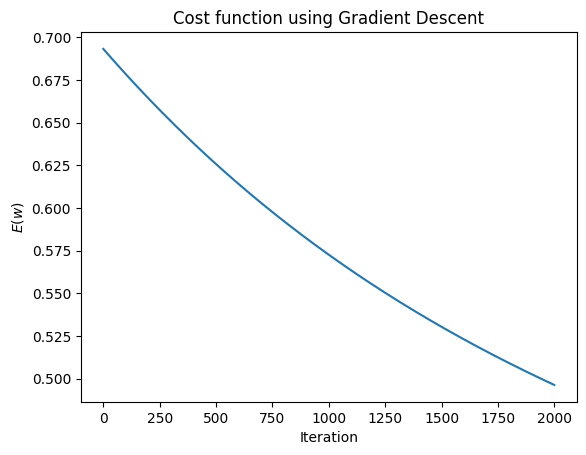

In [ ]:
# Visualizing the change in Cost function versus iterations
plt.plot(E_history)
plt.xlabel("Iteration")
plt.ylabel("$E(w)$")
plt.title("Cost function using Gradient Descent")

## 5. Plotting the Decision Boundary

This final $w$ value can then be used to plot the decision boundary on the training data.
For logistic regression, we have $h_w(x) = \delta(z)$, where $\delta$ is the sigmoid function and $z = w^T * x$. Since $h_w(x) \geq 0.5$ is interpreted as predicting class "1", $\delta(w^Tx) \geq 0.5$ or $w^Tx \geq 0$ predict class "1", we can see that $w^Tx = w_0 + w_1*x_1 + w_2x_2 = 0$ is the decision boundary.

Since we plot $x_1$ against $x_2$, the boundary line will be the equation $ x_2 = \frac{-(w_0+w_1*x_1)}{w_2}$. And here, we will use the normalized version of the original data that we stored in X_norm, the boundary line will use $w$.

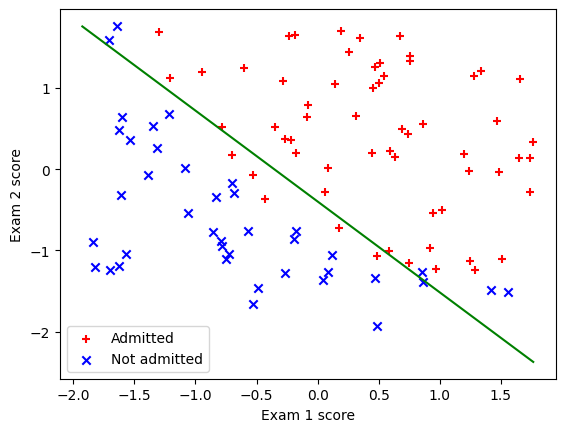

In [ ]:
plt.scatter(X_norm[pos[:,0],0], X_norm[pos[:,0],1], c="r", marker="+", label="Admitted")
plt.scatter(X_norm[neg[:,0],0], X_norm[neg[:,0],1], c="b", marker="x", label="Not admitted")


# Only need 2 points to define a line, so choosing two endpoints:
x_value = np.array([np.min(X_norm[:,1]), np.max(X_norm[:,1])])
y_value =- (w[0] + w[1]*x_value) / w[2]

plt.plot(x_value,y_value, "g")
plt.xlabel("Exam 1 score")
plt.ylabel("Exam 2 score")
plt.legend(loc=0)

## 6. Evaluating Logistic Regression Model

After learning the parameters, using the model to predict whether a particular student will be admitted. For a student with an Exam 1 score of 45 and an Exam 2 score of 85, you should expect to see an admission probability of 0.767.

Another way to evaluate the quality of the parameters we have found is to see how well the learned model predicts on our training set. We will write the predict function that will produce “1” or “0” predictions given a dataset and the learned parameter vector $w$.


In [ ]:
def predict(w, X):
    """ predict- take in numpy array of w and X and returns the predict the labeled outcome """

    h_w = sigmoid(w.T @ X)

    return h_w >= 0.5

In [ ]:
x_test = np.array([45, 85]).reshape(1, 2)
x_test = (x_test - X_mean) / X_std
x_test_t = x_test.T
print(x_test_t.shape)

x_test_new = np.vstack((np.ones((1,1)), x_test_t))
print(x_test_new)

prob = sigmoid(w.T @ x_test_new)
print("For a student with scores 45 and 85, we predict an admission probability of",prob[0,0])

(2, 1)
[[ 1.        ]
 [-1.06629865]
 [ 1.0155961 ]]
For a student with scores 45 and 85, we predict an admission probability of 0.5219103716498372


Now we can also check the accuracy of the model on the training data.

In [ ]:
# get predictions for the training data
# train_pred will an array of (1, 100) with boolean values
train_pred = predict(w, X_new)

# train_label==y will again be a
print("Train Accuracy: ", np.mean(train_pred==y) * 100,"%")

Train Accuracy:  90.0 %


| Expected|
|:-|
Train Accuracy:  89.0 %

## Using for other models

1. Find one dataset for classification on Kaggle.com;
2. Use the model that you built in this notebook to train a logistic regression model;
3. Use sci-kit learn package builtin logistic regression model to train another
4. Compare the model's accuracy with the logistic regression model from the sci-kit learn package.

### **Find one dataset for classification on Kaggle.com;**

In [ ]:
!wget --no-check-certificate https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip
!unzip /content/smsspamcollection.zip

--2026-04-03 08:02:57--  https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘smsspamcollection.zip’

smsspamcollection.z     [ <=>                ] 198.65K  1.10MB/s    in 0.2s    

2026-04-03 08:02:58 (1.10 MB/s) - ‘smsspamcollection.zip’ saved [203415]

Archive:  /content/smsspamcollection.zip
  inflating: SMSSpamCollection       
  inflating: readme                  


In [ ]:
import pandas as pd
import numpy as np

# load dataset and rename columns
df = pd.read_csv('/content/SMSSpamCollection', sep='\t', header=None)
df.columns = ['label', 'message']

# features and labels
X = df['message'].values
y = (df['label'] == 'spam').astype(int).values

print(f'{X[:5]}\n{y[:5]}')

['Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'
 'Ok lar... Joking wif u oni...'
 "Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's"
 'U dun say so early hor... U c already then say...'
 "Nah I don't think he goes to usf, he lives around here though"]
[0 0 1 0 0]


### Use sci-kit learn package builtin logistic regression model to train another

- Convert text to vector of numbers using sklearns TF-IDF

*   Creating test dataset and Predict on unseen dataset

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Convert text to numeric features using vectorizer from sklearn
X = TfidfVectorizer(max_features=3000).fit_transform(X).toarray()
print("X.shape:", X.shape) # feature matrix


# train and test split from sklearn
# - splitting array/matrices into randomized train and test datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X.shape: (5572, 3000)


### Convert to correct dimensions, where

*   X (num_features, N)
*   y (1, N)

### Add bias terms to row



In [ ]:
X_train = X_train.T
X_test = X_test.T

y_train = y_train.reshape(1,-1)
y_test = y_test.reshape(1,-1)

# add bias term
X_train = np.vstack((np.ones((1,X_train.shape[1])), X_train))
X_test = np.vstack((np.ones((1,X_test.shape[1])), X_test))


-

### Use the model that you built in this notebook to train a logistic regression model;


In [ ]:
w = np.zeros((X_train.shape[0],1))
w, E_history = gradient_descent(X= X_train, y= y_train, w= w, alpha= 0.1, num_iters= 400)

print("w optimized by gradient descent:",w)
print("The cost of the optimized w:",E_history[-1])


w optimized by gradient descent: [[-1.81595960e+00]
 [ 1.41728002e-02]
 [ 4.12240467e-02]
 ...
 [-2.65617371e-02]
 [ 8.82060215e-03]
 [-8.29211237e-04]]
The cost of the optimized w: 0.3742530713935576


Because spam classification is much more difficult, therefore a higher cost is expected.

### Evaluate Model

In [ ]:
train_pred = predict(w, X_train)
train_test = predict(w, X_test)

# compare prediction to actual
print("Train Accuracy: ", np.mean(train_pred == y_train) * 100,"%")
print("Test Accuracy: ", np.mean(train_test == y_test) * 100,"%")

Train Accuracy:  86.58290329818263 %
Test Accuracy:  86.63677130044843 %


### Compare the model's accuracy with the logistic regression model from the sci-kit learn package.

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train[1:].T, y_train.ravel())   # remove bias row for sklearn

print("Sklearn Train Accuracy: ", model.score(X_train[1:].T, y_train.ravel()) * 100,"%")
print("Sklearn Test Accuracy: ", model.score(X_test[1:].T, y_test.ravel()) * 100,"%")


Sklearn Train Accuracy:  97.75633834417769 %
Sklearn Test Accuracy:  97.57847533632287 %
